In [1]:
import os
os.chdir('../../../../..')

In [2]:
from typing import List

from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import numpy as np
import polars as pl
import numpy as np
import kmedoids
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.non_euclidean import Wasserstein
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix, build_universal_matrix
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=1000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()
frames = qm9.get_positions(invariant=False)
mol_ids = [frame.info['mol_id'] for frame in frames]
df = df.filter(pl.col("mol_id").is_in(mol_ids))

2026-04-11 16:11:27.745 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-11 16:11:27.890 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=1000, returned_rows=1000.
2026-04-11 16:11:27.891 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=1000).
2026-04-11 16:11:27.891 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).
2026-04-11 16:11:28.506 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_18733: Embedding failed.
2026-04-11 16:11:28.879 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_33751: Embedding failed.
2026-04-11 16:11:29.564 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_51961: Embedding failed.
2026-04-11 16:11:30.344 | DEBUG    | src.datasets:get_positions:1143 - Skipping 

In [4]:
wasserstein = Wasserstein()
distance_matrix = wasserstein.distance_matrix(frames)

Computing Wasserstein distance matrix for 992 feature matrices...


Wasserstein distances: 100%|██████████| 491536/491536 [00:33<00:00, 14848.14pair/s]


Evaluating K-Medoids and Hierarchical Clustering...
K=2 | K-Medoids Score: 0.4541 | Hierarchical Score: 0.7098
K=3 | K-Medoids Score: 0.3942 | Hierarchical Score: 0.4674
K=4 | K-Medoids Score: 0.3470 | Hierarchical Score: 0.4201
K=5 | K-Medoids Score: 0.3208 | Hierarchical Score: 0.3136
K=6 | K-Medoids Score: 0.3397 | Hierarchical Score: 0.3693
K=7 | K-Medoids Score: 0.3482 | Hierarchical Score: 0.3619
K=8 | K-Medoids Score: 0.3374 | Hierarchical Score: 0.3588
K=9 | K-Medoids Score: 0.3372 | Hierarchical Score: 0.3227
K=10 | K-Medoids Score: 0.3334 | Hierarchical Score: 0.2924

Optimal K for K-Medoids: 2 (Score: 0.4541)
Optimal K for Hierarchical: 2 (Score: 0.7098)


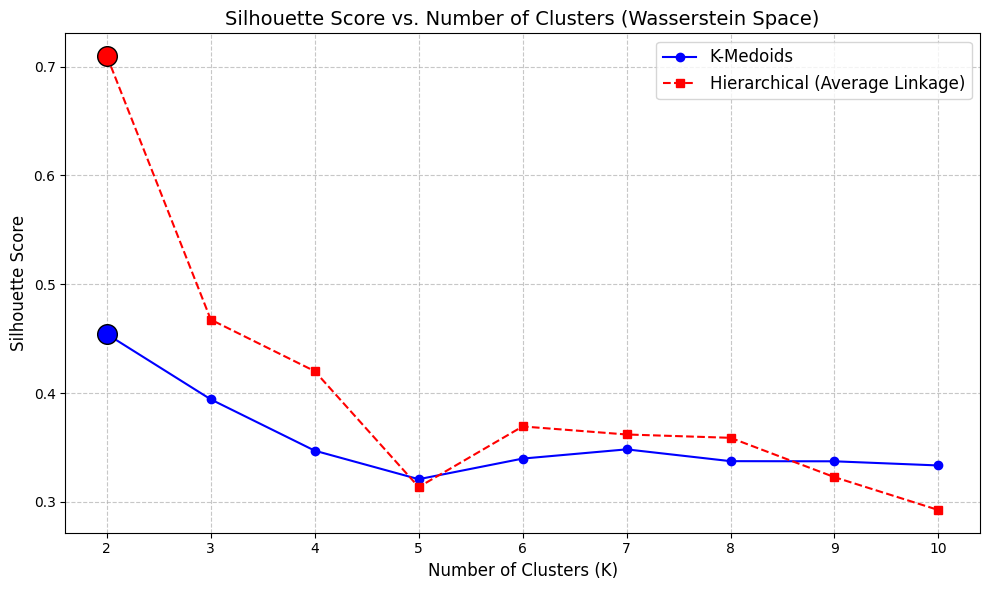

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from kmedoids import KMedoids
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Assuming you already have your distance matrix calculated:
# wasserstein = Wasserstein()
# distance_matrix = wasserstein.distance_matrix(frames)

# Define the range of clusters you want to test (e.g., from 2 to 10)
k_values = range(2, 11)

kmedoids_scores = []
hierarchical_scores = []

print("Evaluating K-Medoids and Hierarchical Clustering...")

for k in k_values:
    # 1. Evaluate K-Medoids
    kmedoids = KMedoids(n_clusters=k, metric='precomputed', random_state=42)
    labels_kmedoids = kmedoids.fit_predict(distance_matrix)
    
    # Calculate Silhouette Score (make sure to pass metric='precomputed')
    score_kmedoids = silhouette_score(distance_matrix, labels_kmedoids, metric='precomputed')
    kmedoids_scores.append(score_kmedoids)
    
    # 2. Evaluate Hierarchical Agglomerative Clustering
    hierarchical = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels_hierarchical = hierarchical.fit_predict(distance_matrix)
    
    score_hierarchical = silhouette_score(distance_matrix, labels_hierarchical, metric='precomputed')
    hierarchical_scores.append(score_hierarchical)
    
    print(f"K={k} | K-Medoids Score: {score_kmedoids:.4f} | Hierarchical Score: {score_hierarchical:.4f}")

# Find the best K for each algorithm
best_k_kmedoids = k_values[np.argmax(kmedoids_scores)]
best_k_hierarchical = k_values[np.argmax(hierarchical_scores)]

print(f"\nOptimal K for K-Medoids: {best_k_kmedoids} (Score: {max(kmedoids_scores):.4f})")
print(f"Optimal K for Hierarchical: {best_k_hierarchical} (Score: {max(hierarchical_scores):.4f})")

# --- Plot the Results ---
plt.figure(figsize=(10, 6))

plt.plot(k_values, kmedoids_scores, marker='o', linestyle='-', color='b', label='K-Medoids')
plt.plot(k_values, hierarchical_scores, marker='s', linestyle='--', color='r', label='Hierarchical (Average Linkage)')

# Mark the best points on the plot
plt.scatter(best_k_kmedoids, max(kmedoids_scores), color='b', s=200, edgecolors='black', zorder=5)
plt.scatter(best_k_hierarchical, max(hierarchical_scores), color='r', s=200, edgecolors='black', zorder=5)

plt.title('Silhouette Score vs. Number of Clusters (Wasserstein Space)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [7]:
agg = AgglomerativeClustering(n_clusters=6, metric='precomputed', linkage='average')
labels = agg.fit_predict(distance_matrix)
df = df.with_columns(cluster_label=labels)

In [11]:
create_chemiscope_viewer(df, distance_matrix, labels, reduction_method='ISOMAP')

Running ISOMAP dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_ISOMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_ISOMAP_clustering.json`.


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 6 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


<ChemiscopeWidget(meta={'name': 'QM9 - ISOMAP Clustering'}, settings={'map': {'x': {'property': 'ISOMAP_1'}, '…

In [18]:
kmedoids = KMedoids(n_clusters=5, metric='precomputed', random_state=42)
labels = kmedoids.fit_predict(distance_matrix)
df = df.with_columns(cluster_label=labels)

In [20]:
create_chemiscope_viewer(df, distance_matrix, labels, reduction_method='MDS')

Running MDS dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_MDS_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_MDS_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…